# EDA: crop features vs groundwater nitrate
Datasets: (DWR crop map 2023) and (crop history: 1997, 2014, 2016, 2018, 2020, 2022).

In [1]:
import zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# one row per well with the target var (nitrate)
wells = pd.read_csv("wells_nitrate.csv")

In [3]:
wells.head()

,well_id,latitude,longitude,x_m,y_m,nitrate_median_mgL,exceeds_10mgL,well_depth_ft
0,01050601,36.828356,-121.676089,-149284.4,-130741.2,15.9,1,NaN
1,AGC100000001-CCGC_0056,36.518767,-121.477083,-132097.1,-165440.3,10.8,1,NaN
2,AGC100000001-CCGC_0365,36.742640,-121.627650,-145134.0,-140342.1,15.0,1,NaN
3,AGC100000001-CCGC_0387,35.879840,-120.887830,-80066.4,-237091.5,8.4,0,NaN
4,AGC100000001-CCGC_0533,36.678410,-121.734550,-154795.6,-147310.6,3.8,0,NaN


In [4]:
target = "nitrate_median_mgL" # median nitrate since 2015
over = "exceeds_10mgL" # 1 if the median is over the 10 mg/L drinking water limit

fig_dir = Path("../../results/eda/crop_mapping")
fig_dir.mkdir(parents=True, exist_ok=True)

## 0. Crop features for each well

In [ ]:
features_file = Path("well_crop_features_all.csv")

# crop map zips are not in git, but you can get them from data.cnra.ca.gov and put them in crop_maps/
# year: (zip file, column with the crop letter, column with the county name)
files = {
    1997: ("i15_landuse_monterey1997.zip", "CLASS1", None),   # already Monterey only
    2014: ("i15_crop_mapping_2014_gdb.zip", "DWR_Standard_Legend", "County"),
    2016: ("i15_crop_mapping_2016_gdb.zip", "Symb_class", "County"),
    2018: ("i15_crop_mapping_2018_gdb.zip", "SYMB_CLASS", "COUNTY"),
    2020: ("i15_crop_mapping_2020_gdb.zip", "SYMB_CLASS", "COUNTY"),
    2022: ("i15_crop_mapping_2022_gdb.zip", "SYMB_CLASS", "COUNTY"),
    2023: ("i15_crop_mapping_2023_final.gdb.zip", "SYMB_CLASS", "COUNTY"),
}
# DWR land use letter -> our crop group
letter_to_group = {
    "T": "veg_berry",
    "V": "vineyard",
    "D": "orchard", "C": "orchard", "Y": "orchard", "YP": "orchard",
    "G": "grain_field_pasture", "F": "grain_field_pasture", "P": "grain_field_pasture", "R": "grain_field_pasture",
    "I": "idle_fallow", "X": "idle_fallow",
}
farmed_groups = ["veg_berry", "vineyard", "orchard", "grain_field_pasture"]
# MULTIUSE letter -> crops grown per year
crops_per_year = {"S": 1, "D": 2, "T": 3, "Q": 4}

Summary of features tested: 

pct_(some crop)_(some radius)
1. pct_veg_berry_...: veggies, berries, etc.
2. pct_vineyard_...: vineyards
3. pct_orchard_...: fruit/nut trees, citrus, avocado, etc.
4. pct_grain_field_pasture_...: grain, hay, etc.
5. pct_idle_fallow_...: idle or fallow fields
6. pct_urban_...: towns (only mapped in 1997)
7. pct_cropland_...: all farmed land added up
8. pct_multicrop_...: land planted 2+ times a year
9. crop_cycles_...: crops planted per year on nearby farmland
10. dist_veg_berry_m_2023: distance to the nearest veggie field

Radius is 1000 m for every year (1997 to 2023), and 500 m for 2023.

In [6]:
if not features_file.exists():
    wells_gdf = gpd.GeoDataFrame(wells[["well_id"]], geometry=gpd.points_from_xy(wells["x_m"], wells["y_m"]), crs=3310)
    print(wells_gdf.head())
    results = []

    for year, (zip_name, code_col, county_col) in files.items():
        print("working on", year)

        zip_path = "crop_maps/" + zip_name
        names = zipfile.ZipFile(zip_path).namelist()
        gdb = [n.split(".gdb")[0] + ".gdb" for n in names if ".gdb" in n]
        shp = [n for n in names if n.endswith(".shp")]
        map_path = "/vsizip/" + zip_path + "/" + (gdb[0] if gdb else shp[0])
        if county_col is None:
            m = gpd.read_file(map_path, engine="pyogrio")
        else:
            m = gpd.read_file(map_path, where=f"{county_col} = 'Monterey'", engine="pyogrio")

        letters = m[code_col].astype(str).str.split("|").str[0].str.strip().str.upper()
        m["group"] = letters.map(letter_to_group).fillna("other")
        m.loc[letters.str.startswith("U"), "group"] = "urban"

        # crops per year is only mapped from 2018 on
        if year >= 2018:
            m["cycles"] = m["MULTIUSE"].map(crops_per_year).fillna(1)
        else:
            m["cycles"] = -1

        m["geometry"] = m.geometry.force_2d()
        m = m.to_crs(3310)
        m["geometry"] = m.geometry.buffer(0)
        m = m.dissolve(by=["group", "cycles"]).reset_index()

        # 500 and 1000 meter radius around the wells
        for radius in ([500, 1000] if year == 2023 else [1000]):
            # cut the crop shapes with a circle around each well, as % of the circle
            circles = wells_gdf.copy()
            circles["geometry"] = wells_gdf.buffer(radius)
            pieces = gpd.overlay(circles, m, how="intersection", keep_geom_type=True)
            pieces["pct"] = pieces.geometry.area / (np.pi * radius ** 2) * 100

            # add up per well and group
            table = pieces.pivot_table(index="well_id", columns="group", values="pct", aggfunc="sum")
            table = table.reindex(index=wells["well_id"], columns=farmed_groups + ["idle_fallow", "urban"]).fillna(0)
            table["cropland"] = table[farmed_groups].sum(axis=1)

            # crops per year (area weighted) and % multi-cropped
            if year >= 2018:
                crop = pieces[pieces["group"].isin(farmed_groups)]
                table["crop_cycles"] = (crop["pct"] * crop["cycles"]).groupby(crop["well_id"]).sum() / crop.groupby("well_id")["pct"].sum()
                table["multicrop"] = crop[crop["cycles"] >= 2].groupby("well_id")["pct"].sum()
                table["multicrop"] = table["multicrop"].fillna(0)

            # names like pct_veg_berry_1000m_2023 and crop_cycles_1000m_2023
            new_names = []
            for col in table.columns:
                if col == "crop_cycles":
                    new_names.append(f"crop_cycles_{radius}m_{year}")
                else:
                    new_names.append(f"pct_{col}_{radius}m_{year}")
            table.columns = new_names
            results.append(table)

    # distance from each well to the nearest vegetable/berry field
    veg_fields = m[m["group"] == "veg_berry"][["geometry"]].explode(index_parts=False)
    nearest = gpd.sjoin_nearest(wells_gdf, veg_fields, distance_col="dist_veg_berry_m_2023")
    results.append(nearest.groupby("well_id")["dist_veg_berry_m_2023"].min())

    features = pd.concat(results, axis=1).round(3)
    features.index.name = "well_id"
    features.reset_index().to_csv(features_file, index=False)

crops = pd.read_csv(features_file) # 67 crop features per well
df = wells.merge(crops, on="well_id")
print(df.shape)

(3042, 75)


In [7]:
print(df.head())

                  well_id   latitude   longitude       x_m       y_m  \
0                01050601  36.828356 -121.676089 -149284.4 -130741.2   
1  AGC100000001-CCGC_0056  36.518767 -121.477083 -132097.1 -165440.3   
2  AGC100000001-CCGC_0365  36.742640 -121.627650 -145134.0 -140342.1   
3  AGC100000001-CCGC_0387  35.879840 -120.887830  -80066.4 -237091.5   
4  AGC100000001-CCGC_0533  36.678410 -121.734550 -154795.6 -147310.6   

   nitrate_median_mgL  exceeds_10mgL  well_depth_ft  pct_veg_berry_1000m_1997  \
0                15.9              1            NaN                     1.412   
1                10.8              1            NaN                    98.054   
2                15.0              1            NaN                    76.496   
3                 8.4              0            NaN                     0.000   
4                 3.8              0            NaN                    85.392   

   pct_vineyard_1000m_1997  ...  pct_veg_berry_1000m_2023  \
0                  

/sessions/rcw-01ttuxgrst35etbvykxuxgw5/.local/lib/python3.10/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


/sessions/rcw-01ttuxgrst35etbvykxuxgw5/.local/lib/python3.10/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


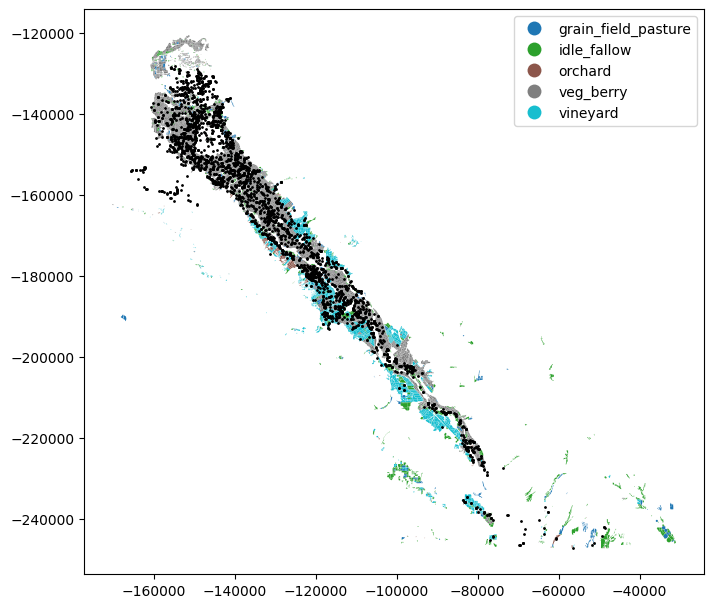

In [8]:
# map of the 2023 crops
zip_path = "crop_maps/i15_crop_mapping_2023_final.gdb.zip"
crop_map = gpd.read_file("/vsizip/" + zip_path + "/i15_Crop_Mapping_2023_Final.gdb", where="COUNTY = 'Monterey'")
crop_map["group"] = crop_map["SYMB_CLASS"].str.strip().map(letter_to_group).fillna("other")
# coordinate transformation for map
crop_map = crop_map.to_crs(3310)

fig, ax = plt.subplots(figsize=(8, 10))
crop_map.plot(ax=ax, column="group", legend=True, cmap="tab10")
# Plotting the wells over the crops
ax.scatter(wells["x_m"], wells["y_m"], s=1, color="black")
plt.savefig(fig_dir / "map_crops_2023.png")
plt.show()

In [9]:
features_2023 = [c for c in crops.columns if c.endswith("1000m_2023") and "urban" not in c] + ["dist_veg_berry_m_2023"]
cols = features_2023 + [target]

stats = df[cols].describe().T
stats["% zero"] = (df[cols] == 0).mean() * 100
stats["% missing"] = df[cols].isna().mean() * 100
stats["corr with target"] = df[cols].corrwith(df[target], method="spearman")
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,% zero,% missing,corr with target
pct_veg_berry_1000m_2023,3042.0,51.94,30.80,0.0,25.05,59.23,80.00,94.83,8.71,0.00,0.10
pct_vineyard_1000m_2023,3042.0,8.23,17.92,0.0,0.00,0.00,3.40,87.77,66.57,0.00,0.05
pct_orchard_1000m_2023,3042.0,0.52,2.67,0.0,0.00,0.00,0.00,26.18,89.97,0.00,-0.02
pct_grain_field_pasture_1000m_2023,3042.0,1.26,3.07,0.0,0.00,0.00,1.29,31.50,55.16,0.00,0.12
pct_idle_fallow_1000m_2023,3042.0,2.71,5.11,0.0,0.00,0.74,3.02,47.26,32.05,0.00,0.12
pct_cropland_1000m_2023,3042.0,61.95,27.26,0.0,48.48,70.04,83.87,94.83,5.36,0.00,0.10
crop_cycles_1000m_2023,2879.0,1.65,0.41,1.0,1.33,1.69,1.95,3.13,0.00,5.36,0.12
pct_multicrop_1000m_2023,3042.0,34.64,25.64,0.0,10.54,33.84,55.73,88.83,13.38,0.00,0.15
dist_veg_berry_m_2023,3042.0,356.97,1151.86,0.0,5.13,16.34,113.75,12975.68,12.10,0.00,-0.14
nitrate_median_mgL,3042.0,14.20,21.67,0.0,1.30,5.30,17.10,204.09,0.26,0.00,1.00


## 1. Distributions

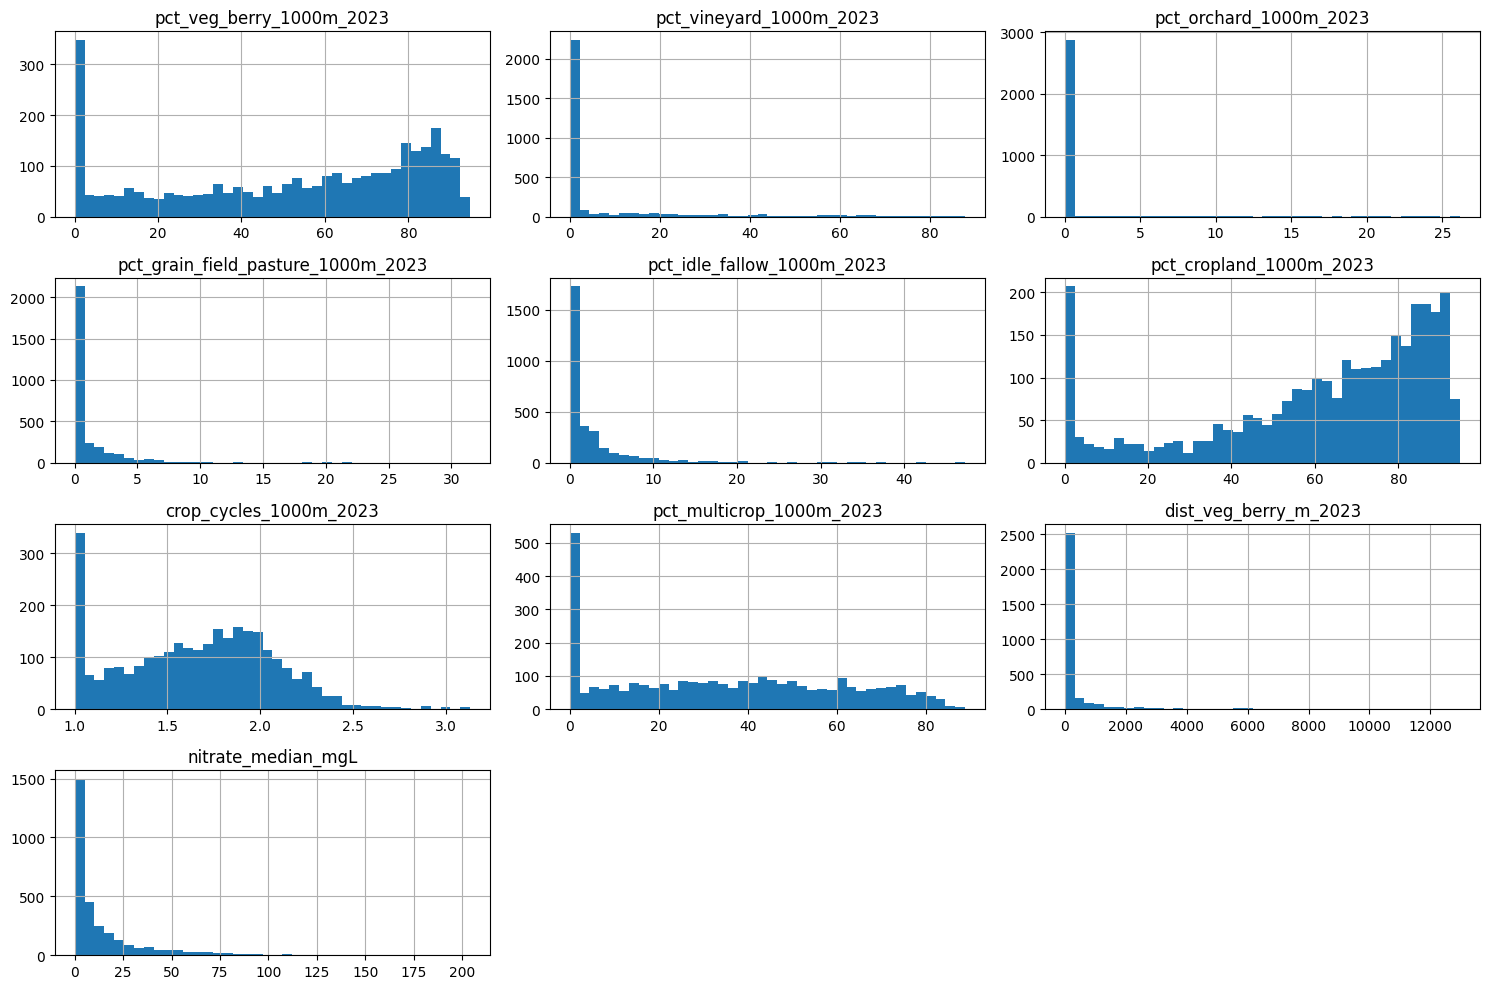

In [10]:
df[cols].hist(bins=40, figsize=(15, 10))
plt.tight_layout()
plt.savefig(fig_dir / "distributions.png")
plt.show()

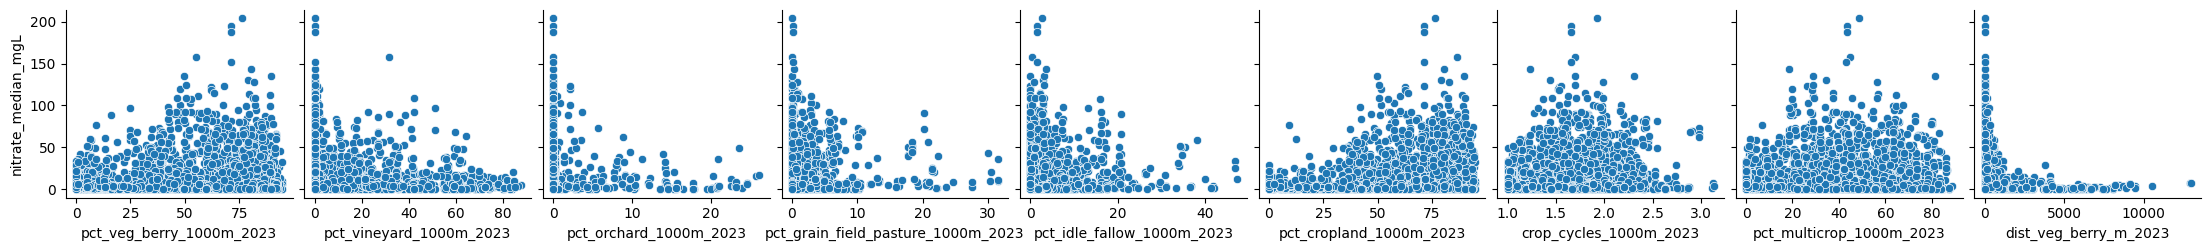

In [11]:
# scatter of the target against each feature
sns.pairplot(df, x_vars=features_2023, y_vars=[target])
plt.savefig(fig_dir / "target_vs_features.png")
plt.show()

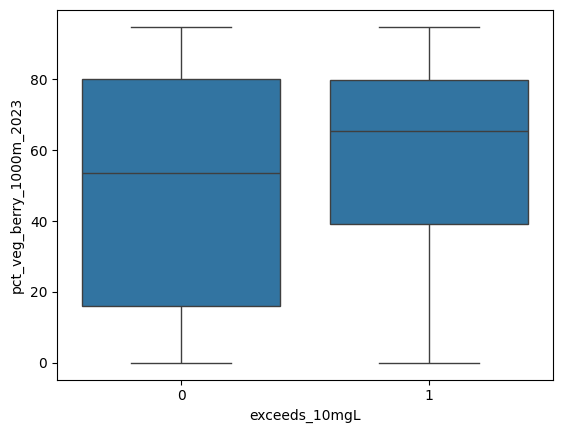

In [12]:
# veg berry for wells under (0) vs over (1) the limit
sns.boxplot(data=df, x=over, y="pct_veg_berry_1000m_2023")
plt.savefig(fig_dir / "boxplot_veg_berry.png")
plt.show()

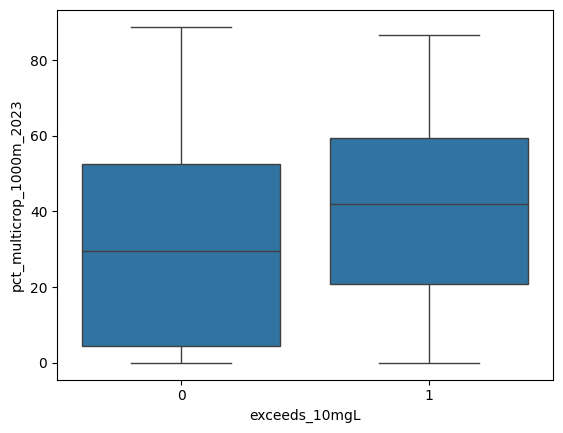

In [13]:
# multi-cropping for wells under (0) vs over (1) the limit
sns.boxplot(data=df, x=over, y="pct_multicrop_1000m_2023")
plt.savefig(fig_dir / "boxplot_multicrop.png")
plt.show()

## 2. Missing Data

pct_veg_berry_1000m_2023              0.0
pct_vineyard_1000m_2023               0.0
pct_orchard_1000m_2023                0.0
pct_grain_field_pasture_1000m_2023    0.0
pct_idle_fallow_1000m_2023            0.0
pct_cropland_1000m_2023               0.0
crop_cycles_1000m_2023                5.4
pct_multicrop_1000m_2023              0.0
dist_veg_berry_m_2023                 0.0
dtype: float64
wells with no cropland within 1 km: 163


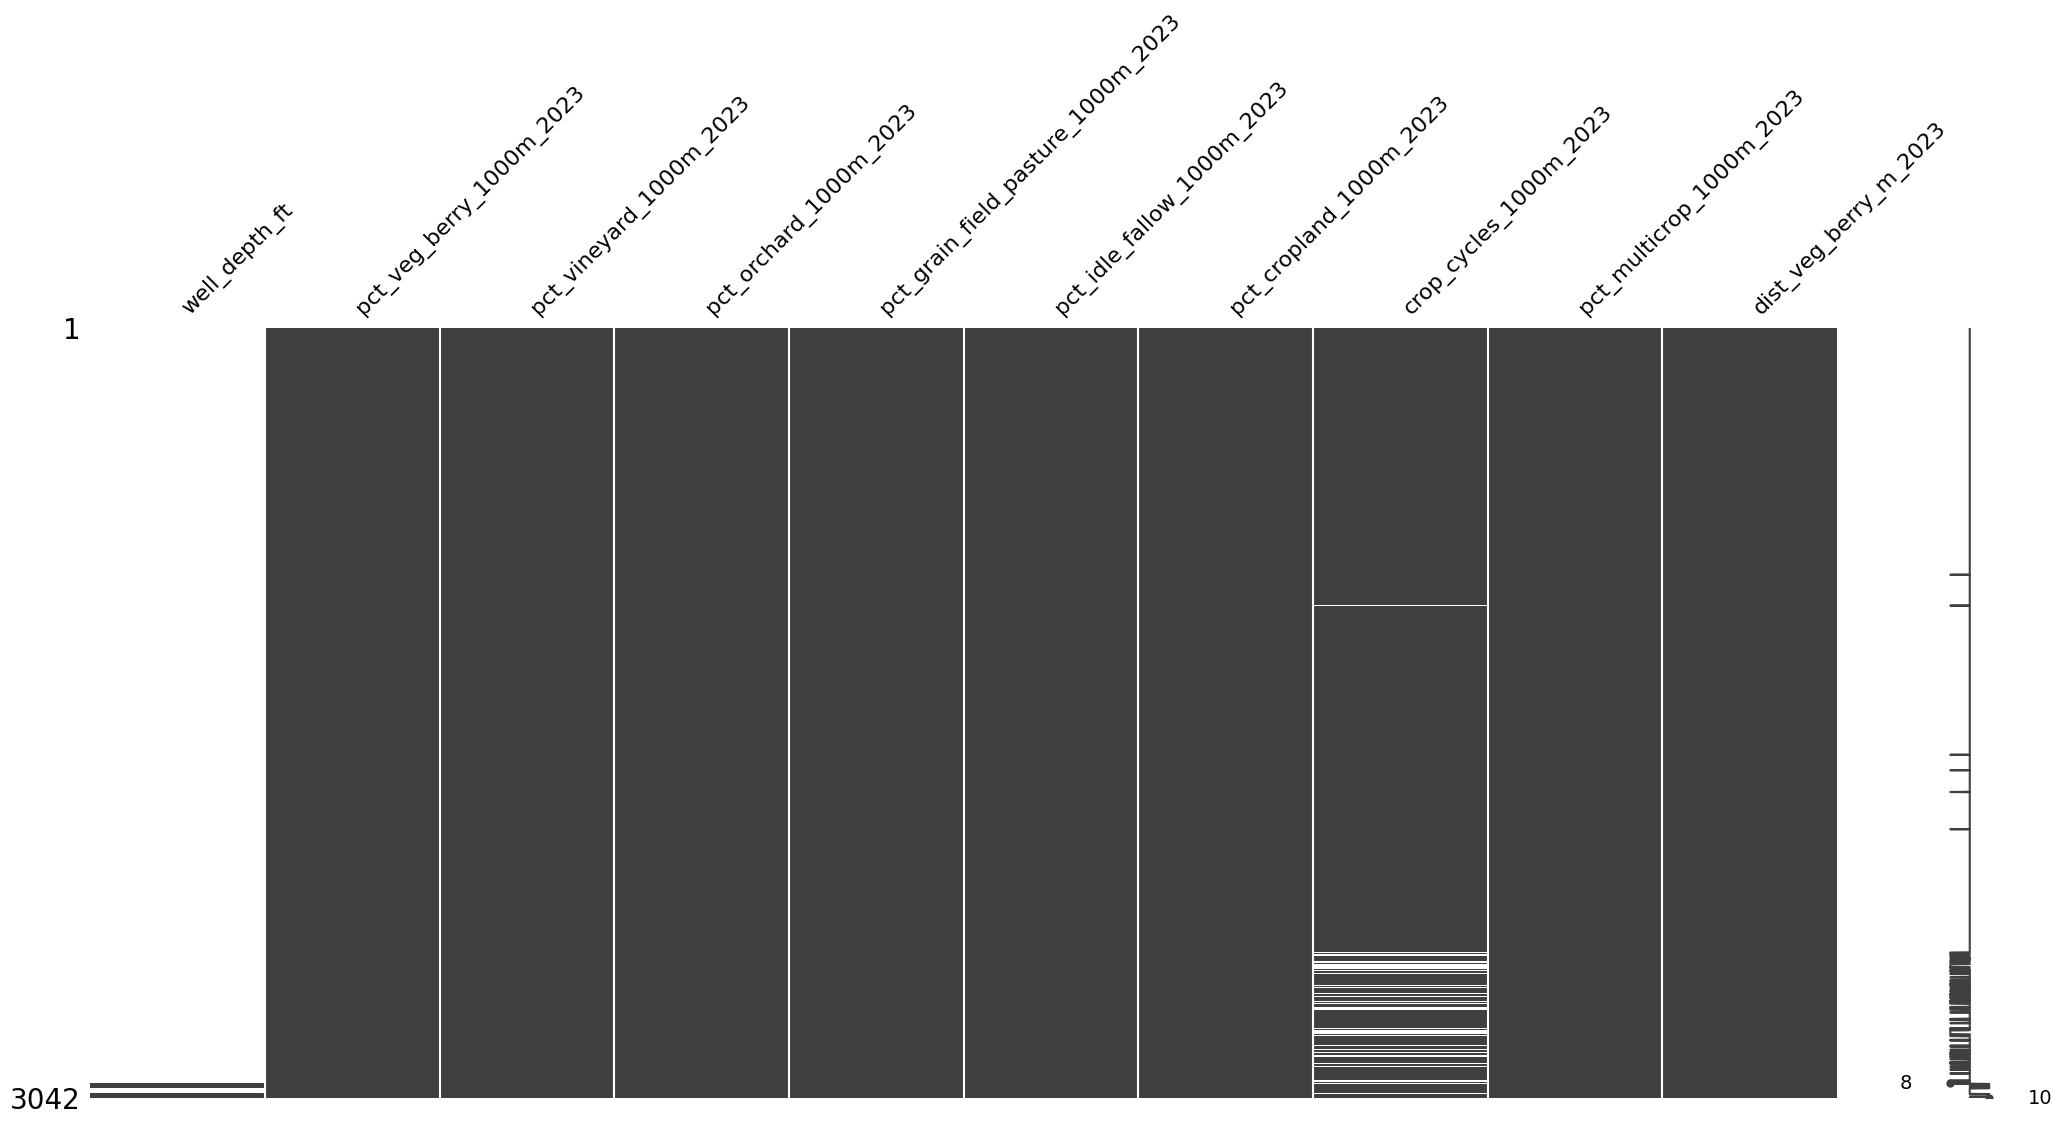

In [14]:
# only crop_cycles: wells with no cropland nearby have no crops to count
print((df[features_2023].isna().mean() * 100).round(1))
print("wells with no cropland within 1 km:", (df["pct_cropland_1000m_2023"] == 0).sum())

msno.matrix(df[["well_depth_ft"] + features_2023])
plt.savefig(fig_dir / "missingness.png")
plt.show()

## 3. Relationships

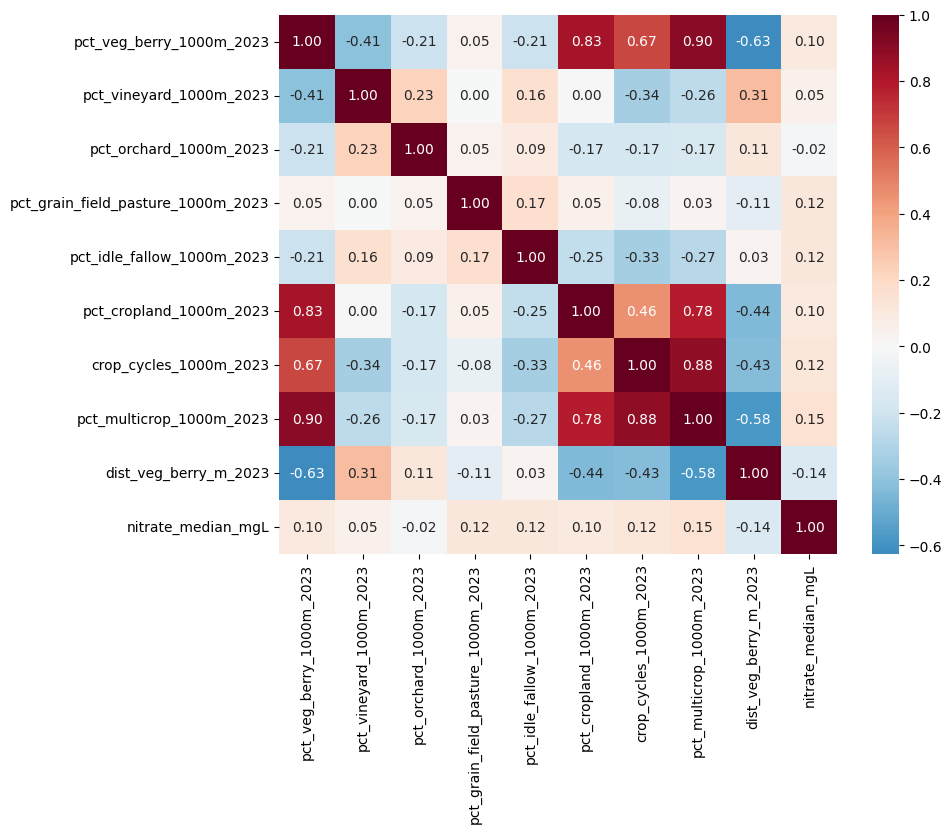

In [15]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[cols].corr(method="spearman"), cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.savefig(fig_dir / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

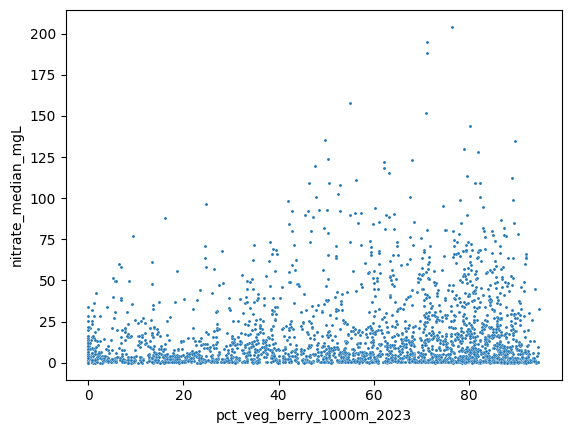

In [16]:
sns.scatterplot(data=df, x="pct_veg_berry_1000m_2023", y=target, s=5)
plt.savefig(fig_dir / "scatter_veg_berry.png")
plt.show()

## 4. Outliers

target values with abs(z) > 3: 71
         pct_vineyard_1000m_2023  nitrate_median_mgL
outlier                                             
False                     0.0000                5.29
True                      0.7035                5.85


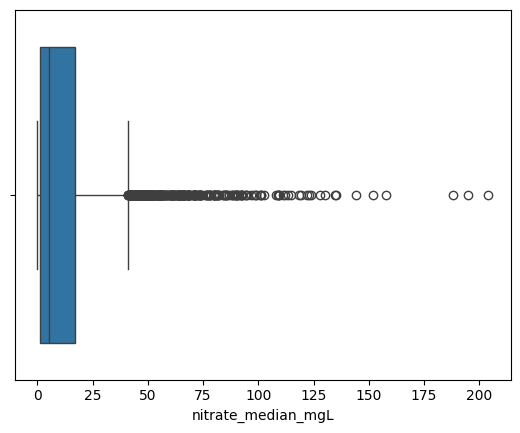

In [17]:
print("target values with abs(z) > 3:", (np.abs(zscore(df[target])) > 3).sum())

outlier = IsolationForest(contamination=0.02, random_state=0).fit_predict(df[features_2023].fillna(0))
df["outlier"] = outlier == -1
print(df.groupby("outlier")[["pct_vineyard_1000m_2023", "nitrate_median_mgL"]].median())

sns.boxplot(x=df[target])
plt.savefig(fig_dir / "target_boxplot.png")
plt.show()

## 5. Lag
Does an older crop map relate to today's nitrate better than the 2023 map?

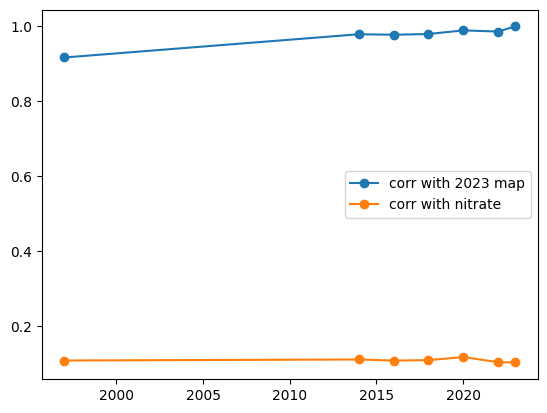

      corr with 2023 map  corr with nitrate
1997            0.917192           0.108358
2014            0.979306           0.111079
2016            0.977967           0.108106
2018            0.979852           0.109342
2020            0.989566           0.117574
2022            0.986488           0.103993
2023            1.000000           0.103079


In [18]:
years = [1997, 2014, 2016, 2018, 2020, 2022, 2023]
lag = pd.DataFrame(index=years)
lag["corr with 2023 map"] = [df[f"pct_veg_berry_1000m_{y}"].corr(df["pct_veg_berry_1000m_2023"], method="spearman") for y in years]
lag["corr with nitrate"] = [df[f"pct_veg_berry_1000m_{y}"].corr(df[target], method="spearman") for y in years]

lag.plot(marker="o")
plt.savefig(fig_dir / "crop_history_lag.png")
plt.show()
print(lag)

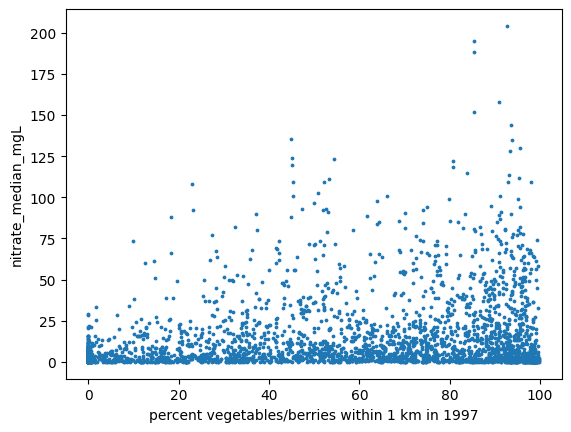

In [19]:
# lag-target scatter plot vegetables in 1997 vs nitrate today
plt.scatter(df["pct_veg_berry_1000m_1997"], df[target], s=3)
plt.xlabel("percent vegetables/berries within 1 km in 1997")
plt.ylabel(target)
plt.savefig(fig_dir / "lag_scatter_1997.png")
plt.show()